In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import multivariate_normal as mvn

In [2]:
import os
os.chdir('c:\\Users\\Mikael Huff\\Documents\\Training')
os.getcwd()

'c:\\Users\\Mikael Huff\\Documents\\Training'

In [8]:
mnist_train = pd.read_csv('data/MNIST_train.csv', index_col="Unnamed: 0")

In [54]:
mnist_test = pd.read_csv('data/MNIST_test.csv', index_col="Unnamed: 0")

In [55]:
mnist_train

,index,labels,0,1,2,3,4,5,6,7,...,774,775,776,777,778,779,780,781,782,783
0,0,5,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,2,4,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,3,1,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,4,9,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
59995,59995,8,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
59996,59996,3,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
59997,59997,5,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
59998,59998,6,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [56]:
mnist_test

,index,labels,0,1,2,3,4,5,6,7,...,774,775,776,777,778,779,780,781,782,783
0,0,7,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,1,2,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,2,1,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,3,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,4,4,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,9995,2,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
9996,9996,3,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
9997,9997,4,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
9998,9998,5,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [57]:
ALL = mnist_train.to_numpy()
X = ALL[:,2:]
y = ALL[:,1]
print(X.shape,y.shape)

(60000, 784) (60000,)


In [58]:
def show_me(X):
    plt.ishow(X.reshape(28,28))

In [35]:
def show_me_all_mean(X, y, k):
    average = np.mean(X[y==k],axis=0)
    plt.imshow(average.reshape(28,28))

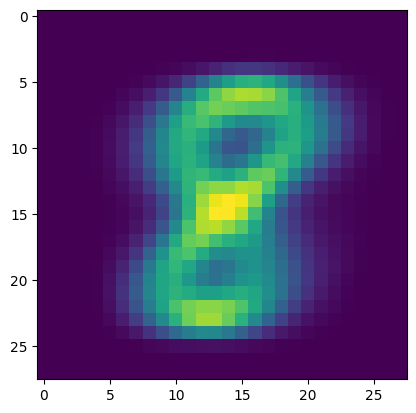

In [78]:

show_me_all_mean(X,y,8)
# np.mean(X[y==5],axis=0).shape

In [59]:
ALL_test = mnist_test.to_numpy()
X_test = ALL_test[:,2:]
y_test = ALL_test[:,1]
print(X_test.shape,y_test.shape)

(10000, 784) (10000,)


## Naive Bayes Classifier on MNIST

In [46]:
class GaussNB():

    def fit(self, X, y, epsilon=1e-3):
        self.likelihoods = dict()
        self.priors = dict()
        self.K = set(y.astype(int))

        for k in self.K:
            X_k = X[y==k]
            self.likelihoods[k] = {'mean':X_k.mean(axis=0), 'cov':X_k.var(axis=0)+epsilon}
            self.priors[k] = len(X_k)/len(X)
    
    def predict(self, X):
        N, d = X.shape
        P_hat = np.zeros((N, len(self.K)))

        for k,l in self.likelihoods.items():
            P_hat[:,k] = mvn.logpdf(X, l['mean'], l['cov']) + np.log(self.priors[k])
        
        return P_hat.argmax(axis=1)
def accuracy(y, y_hat):
    return np.mean(y==y_hat)

In [ ]:
gnb = GaussNB()
gnb.fit(X,y)
y_hat_train = gnb.predict(X)

np.float64(0.5938)

In [60]:
y_hat_test = gnb.predict(X_test)

In [61]:

accuracy(y,y_hat_train)

np.float64(0.5938)

In [62]:
accuracy(y_test,y_hat_test)

np.float64(0.5878)

In [72]:
def ConfusionMatrix(y,y_hat):
    plt.figure(figsize=(10,7))
    y_actu = pd.Series(y, name='Actual')
    y_pred = pd.Series(y_hat, name='Predicted')
    cm = pd.crosstab(y_actu, y_pred)
    ax = sns.heatmap(cm, annot=True, fmt="d")
    plt.ylabel('True label')
    plt.xlabel('Predicted label')

In [65]:
X_scaled = X/255
X_test_scaled = X_test/255
gnb_scaled = GaussNB()
gnb_scaled.fit(X_scaled,y)
y_hat_test_scaled = gnb_scaled.predict(X_test_scaled)

In [66]:
accuracy(y_test,y_hat_test_scaled)

np.float64(0.7746)

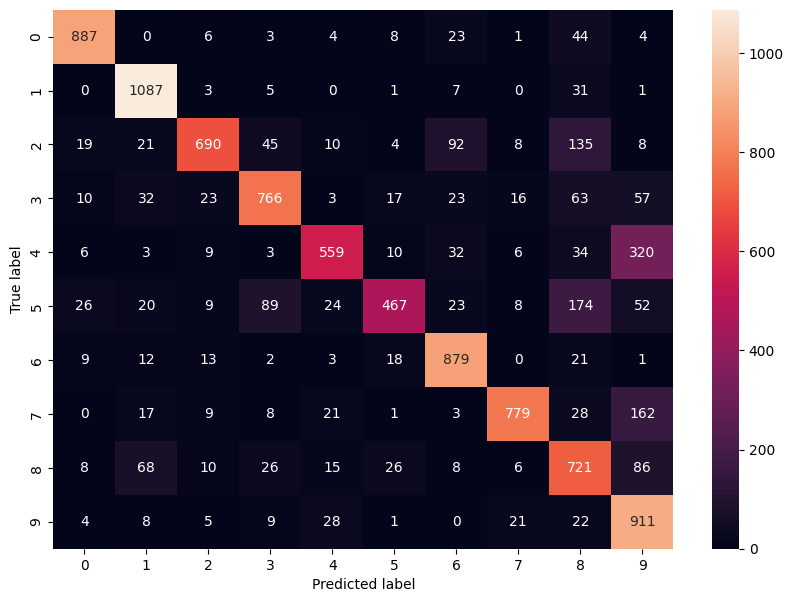

In [73]:
ConfusionMatrix(y_test,y_hat_test_scaled)

In [79]:
class GaussBayes():

    def fit(self, X, y, epsilon=1e-3):
        self.params = {}
        self.priors = {}

        self.K = set(y.astype(int))
        
        for k in self.K:
            X_k = X[y==k,:]
            N_k, d = X_k.shape
            mu_k = X_k.mean(axis=0)
            cov_k = (1/(N_k-1)) * np.matmul((X_k-mu_k).T, (X_k-mu_k))+epsilon*np.identity(d)
            self.params[k] = {'mean':mu_k, 'cov':cov_k}
            self.priors[k] = len(X_k)/len(X)

    def predict(self, X):
        N, d = X.shape
        P_hat = np.zeros((N, len(self.K)))

        for k, l in self.params.items():
            P_hat[:,k] = mvn.logpdf(X, l['mean'], l['cov']) + np.log(self.priors[k])

        return P_hat.argmax(axis=1)


In [80]:
gaussb = GaussBayes()
gaussb.fit(X_scaled, y)
y_hat_gauss_test = gaussb.predict(X_test_scaled)

In [81]:
accuracy(y_test,y_hat_gauss_test)

np.float64(0.9108)

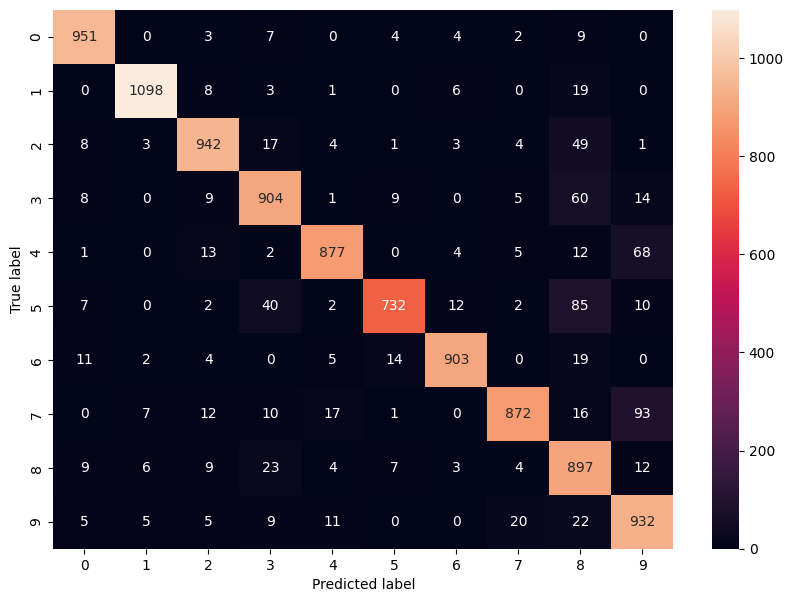

In [83]:
ConfusionMatrix(y_test, y_hat_gauss_test)

# Introduction to Neural Nets

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [84]:
from matplotlib.colors import ListedColormap
cmap_bold = ListedColormap(['#FF0000','#0000FF'])
cmap_light= ListedColormap(['#FFBBBB','#BBBBFF'])

Useful Functions

In [132]:
def sigmoid(h):
    return 1/(1+np.exp(-h))

def cross_entropy(y, p_hat):
    return -(1/len(y))*np.sum(y*np.log(p_hat) + (1-y)*np.log(1-p_hat))

def accuracy(y, y_hat):
    return np.mean(y==y_hat)

### Simple Logistic Regression Class

In [ ]:
class LogisticRegression():
    def __init__(self, thresh=.5):
        self.thresh = thresh
        self.W = None
        self.b = None
    
    def fit(self, X, y, alpha=1e-3, epochs=1e3, show_curve=True):
        epochs = int(epochs)
        N, d = X.shape

        # Random Weights Intialization
        self.W = np.random.randn(d)
        self.b = np.random.randn(1)

        # Build Container for Losses
        L = np.zeros(epochs)

        # SGD Progression
        for epoch in range(epochs):
            p_hat = self.__forward__(X)
            L[epoch] = cross_entropy(y, p_hat)
            # Weights and Biases Update Rules
            # print(self.W.shape)
            self.W -= alpha * (1/N) * X.T @ (p_hat-y)
            
            # print(self.W.shape)
            # break
            self.b -= alpha * (1/N) * np.sum(p_hat-y)
            # if epoch % 200 == 0:
            #     print(epoch+1, end='  ')

        if show_curve:
            plt.figure()
            plt.plot(L)
            plt.xlabel('epochs')
            plt.ylabel('$\\mathcal{L}$')
            plt.title('Training Curve')
        
        

    def __forward__(self, X):
        # print(X.shape, self.W.shape, self.b.shape)
        return sigmoid(X@self.W + self.b)
        
    def predict(self, X):
        return (self.__forward__(X) > self.thresh).astype(np.int32)



In [141]:
def main():
    N = 1000
    D = 2

    X0 = np.random.randn((N//2),D) + np.array([1, 1])
    X1 = np.random.randn((N//2),D) + np.array([-1, -1.5])
    X = np.vstack((X0, X1))

    y = np.array([0]*(N//2) + [1]*(N//2))

    plt.figure()
    plt.scatter(X[:,0], X[:,1], c = y, alpha = 0.5)
    plt.show()
    log_reg = LogisticRegression()
    log_reg.fit(X, y, alpha=1e-3, epochs=1e4)
    y_hat = log_reg.predict(X)
    print(f"Training Accuracy: {accuracy(y,y_hat): .4f}")
    
    # Visualize Desision Boundary
    x1 = np.linspace(X[:,0].min()-1,X[:,0].max()+1, 1000)
    x2 =-(log_reg.b/log_reg.W[1])-(log_reg.W[0]/log_reg.W[1])*x1

    plt.figure()
    plt.scatter(X[:,0], X[:,1], c=y, s=7, alpha=0.5)
    plt.plot(x1,x2, color="#000000", linewidth=2)
    plt.show()

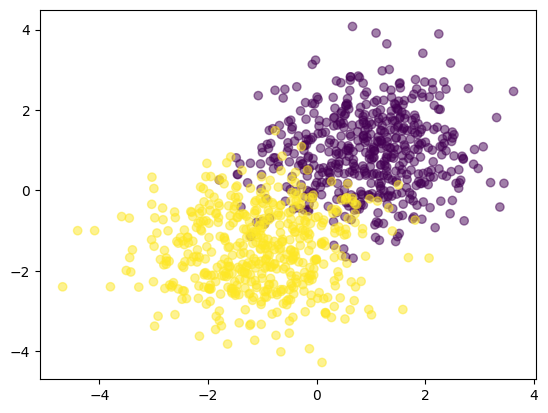

2
Training Accuracy:  0.9210


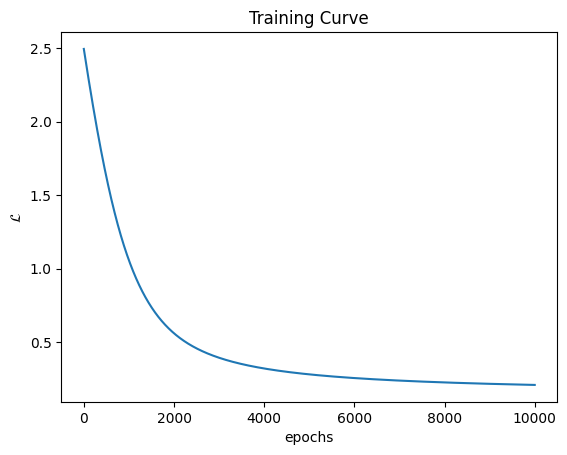

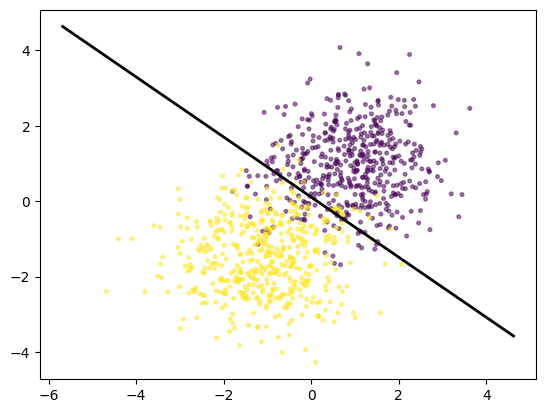

In [142]:
if __name__ == "__main__":
    main()

In [ ]:
class Solution:
    def minScoreTriangulation(self, values: list[int]) -> int:
        
        return self.recur(values)
    
    def recur(self, values):
        # print(values)
        if len(values) == 3:
            # print(values, self.prod(values, 0))
            return self.prod(values, 0)
        min_val = float('inf')
        for i in range(len(values)):
            temp = values.copy()
            temp.pop(i)
            # print(temp)
            val = self.recur(temp) + self.prod(values, i)
            if val < min_val:
                min_val = val

        # print(values, min_val)
        return min_val
        

    def prod(self, values, index):
        val = values[index] * values[index-1] * values[(index+1)%len(values)]
        return val
        

vals = [1,2,3]
vals2 = [3,7,4,5]
vals3 = [1,3,1,4,1,5]
s = Solution()
s.minScoreTriangulation(vals3)

[4, 1, 5] 20
[1, 1, 5] 5
[1, 4, 5] 20
[1, 4, 1] 4
[1, 4, 1, 5] 9
[4, 1, 5] 20
[3, 1, 5] 15
[3, 4, 5] 60
[3, 4, 1] 12
[3, 4, 1, 5] 27
[1, 1, 5] 5
[3, 1, 5] 15
[3, 1, 5] 15
[3, 1, 1] 3
[3, 1, 1, 5] 18
[1, 4, 5] 20
[3, 4, 5] 60
[3, 1, 5] 15
[3, 1, 4] 12
[3, 1, 4, 5] 35
[1, 4, 1] 4
[3, 4, 1] 12
[3, 1, 1] 3
[3, 1, 4] 12
[3, 1, 4, 1] 7
[3, 1, 4, 1, 5] 22
[4, 1, 5] 20
[1, 1, 5] 5
[1, 4, 5] 20
[1, 4, 1] 4
[1, 4, 1, 5] 9
[4, 1, 5] 20
[1, 1, 5] 5
[1, 4, 5] 20
[1, 4, 1] 4
[1, 4, 1, 5] 9
[1, 1, 5] 5
[1, 1, 5] 5
[1, 1, 5] 5
[1, 1, 1] 1
[1, 1, 1, 5] 6
[1, 4, 5] 20
[1, 4, 5] 20
[1, 1, 5] 5
[1, 1, 4] 4
[1, 1, 4, 5] 24
[1, 4, 1] 4
[1, 4, 1] 4
[1, 1, 1] 1
[1, 1, 4] 4
[1, 1, 4, 1] 5
[1, 1, 4, 1, 5] 10
[4, 1, 5] 20
[3, 1, 5] 15
[3, 4, 5] 60
[3, 4, 1] 12
[3, 4, 1, 5] 27
[4, 1, 5] 20
[1, 1, 5] 5
[1, 4, 5] 20
[1, 4, 1] 4
[1, 4, 1, 5] 9
[3, 1, 5] 15
[1, 1, 5] 5
[1, 3, 5] 15
[1, 3, 1] 3
[1, 3, 1, 5] 8
[3, 4, 5] 60
[1, 4, 5] 20
[1, 3, 5] 15
[1, 3, 4] 12
[1, 3, 4, 5] 32
[3, 4, 1] 12
[1, 4, 1] 4
[1, 3, 1] 3
[1, 3

13

In [157]:
vals2[-1:2]

[]